# Cloud-Chamber Particle-Track Detection with YOLO11

An end-to-end object-detection pipeline that identifies particle tracks in cloud-chamber
footage using **YOLO11n**. This is an alternative to the Skeletonisation + RandomForest
approach.

**Classes detected**

| id | class | meaning |
|----|-------|---------|
| 0 | `Alpha` | thick, short alpha-particle tracks |
| 1 | `Proton` | proton recoil tracks |
| 2 | `Electron_Positron_Muon` | e⁻ / e⁺ / muon tracks |
| 3 | `Low_Energy_Electron` | low-energy electron squiggles |
| 4 | `Knock_On_Electron` | knock-on (delta) electrons |

**Pipeline**
1. Convert the red-box annotated images in `../Images` into a YOLO dataset (the red boxes
   are *inpainted away* so the model learns the track, not the annotation).
2. Train YOLO11n on the train/val split.
3. Inspect training metrics.
4. Run inference on a single image and on a video.

> **Environment:** run this notebook with the `rocm_env` conda interpreter
> (`C:\Users\PC\anaconda3\envs\rocm_env\python.exe`). On this machine the AMD ROCm GPU
> hits a MIOpen kernel-compile bug during training, so training is done on **CPU**
> (`device="cpu"`). Inference works on either.


## 1. Setup

Import the project modules and check the environment (Torch / Ultralytics / GPU).
All the logic lives in the sibling `.py` files so the notebook stays thin:

- `config.py` — classes, colours, paths, hyper-parameters
- `prepare_dataset.py` — red-box → YOLO-label conversion + inpainting
- `train.py` — training wrapper (with automatic CPU fallback)
- `inference.py` — image / video detection helpers


In [1]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

import config
import prepare_dataset
import inference

%matplotlib inline

print(f"Torch            : {torch.__version__}")
print(f"CUDA/ROCm avail  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device       : {torch.cuda.get_device_name(0)}")
print(f"Classes ({config.NUM_CLASSES}): {config.CLASS_NAMES}")
print(f"Images dir       : {os.path.abspath(config.IMAGES_DIR)}")
print(f"Dataset dir      : {config.DATASET_DIR}")


Torch            : 2.9.1+rocm7.2.1
CUDA/ROCm avail  : True
GPU device       : AMD Radeon RX 9060 XT
Classes (5): ['Alpha', 'Proton', 'Electron_Positron_Muon', 'Low_Energy_Electron', 'Knock_On_Electron']
Images dir       : c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\Images
Dataset dir      : c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\dataset


## 2. Build the YOLO dataset

`prepare_dataset.prepare()` walks every entry in `config.IMAGE_LABEL_MAP`, detects the red
annotation rectangles, converts them to normalised YOLO labels, **inpaints the red boxes
away**, and writes a reproducible train/val split plus `data.yaml`.

> Re-running this cell rebuilds the dataset from scratch (it clears `dataset/images` and
> `dataset/labels` first).


In [12]:
stats = prepare_dataset.prepare(verbose=True)


DATASET PREPARATION SUMMARY
  Train images: 26
  Val images:   6
  Total boxes:  36

  Boxes per class:
    0 Alpha                    7
    1 Proton                   9
    2 Electron_Positron_Muon   11
    3 Low_Energy_Electron      5
    4 Knock_On_Electron        4

  Box/label count mismatches (name, boxes, labels):
    VID_20220609_215401_A.mp4_snapshot_01.20_[2022.06.10_12.57.12].jpg: 1 boxes vs 2 labels
    VID_20220609_221024_A.mp4_snapshot_01.21_[2022.06.10_18.30.35].jpg: 1 boxes vs 2 labels

  data.yaml -> c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\dataset\data.yaml


## 3. Sanity-check the labels

Draw the generated YOLO labels back onto a few (inpainted) training images. The boxes
should sit on the tracks and the original **red annotation rectangles should be gone**.


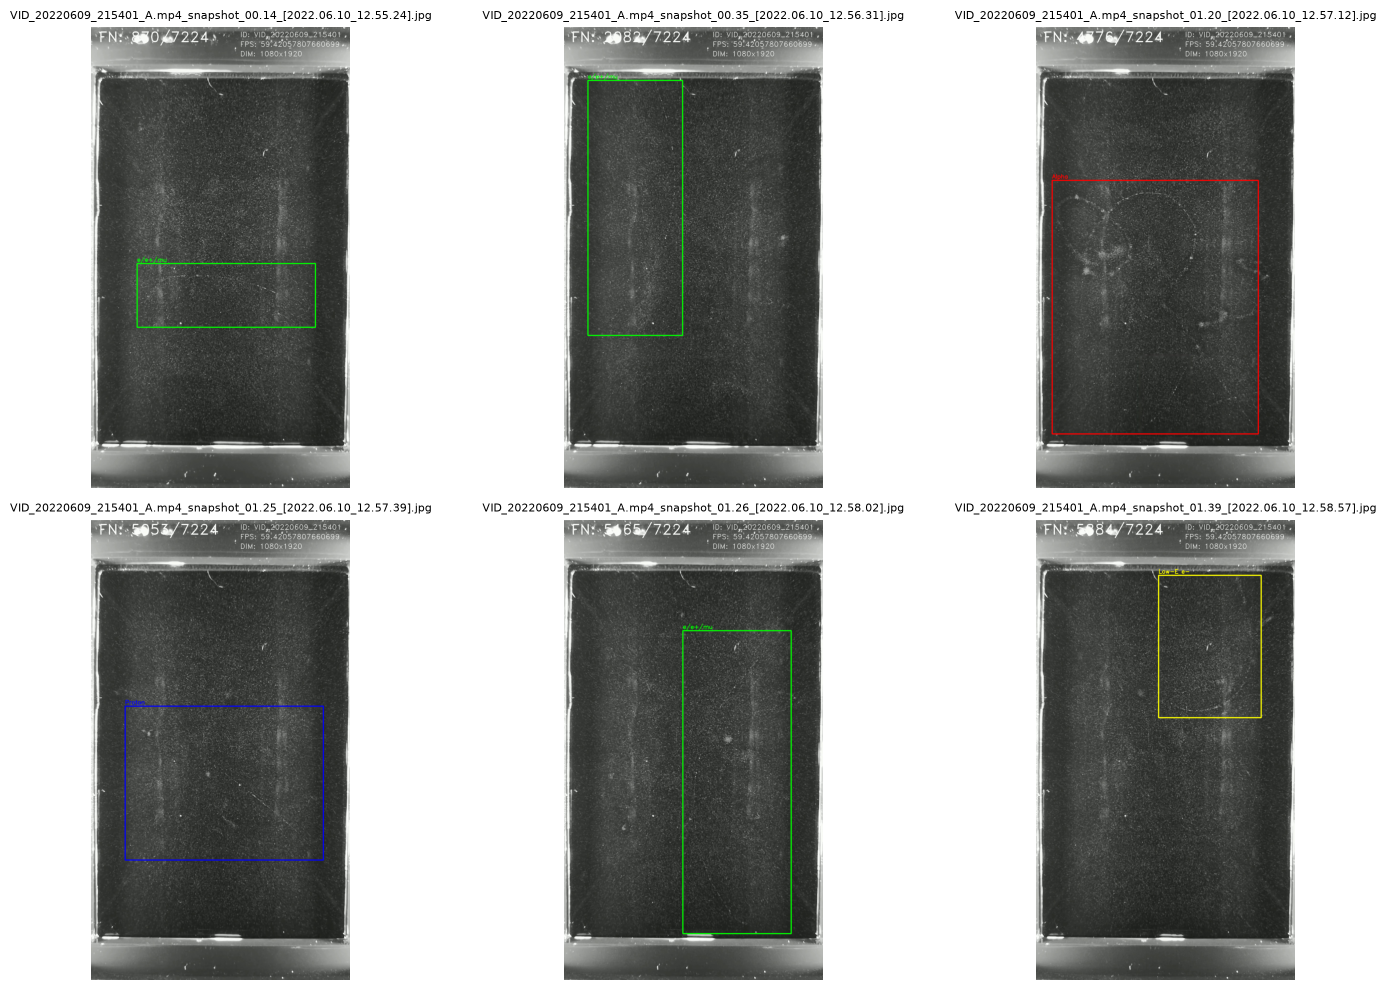

In [13]:
def draw_yolo_labels(img_path, label_path):
    """Draw normalised YOLO labels (cls cx cy w h) onto an image (BGR->RGB)."""
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    if os.path.isfile(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = (float(v) for v in parts[1:])
                x1 = int((cx - bw / 2) * w)
                y1 = int((cy - bh / 2) * h)
                x2 = int((cx + bw / 2) * w)
                y2 = int((cy + bh / 2) * h)
                color = config.CLASS_COLORS.get(cls_id, (255, 255, 255))
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
                cv2.putText(img, config.DISPLAY_NAMES.get(cls_id, str(cls_id)),
                            (x1, max(0, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX,
                            0.8, color, 2)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


train_img_dir = os.path.join(config.DATASET_DIR, "images", "train")
train_lbl_dir = os.path.join(config.DATASET_DIR, "labels", "train")
samples = sorted(os.listdir(train_img_dir))[:6]

cols = 3
rows = (len(samples) + cols - 1) // cols
plt.figure(figsize=(16, 5 * rows))
for i, name in enumerate(samples):
    img_path = os.path.join(train_img_dir, name)
    lbl_path = os.path.join(train_lbl_dir, os.path.splitext(name)[0] + ".txt")
    plt.subplot(rows, cols, i + 1)
    plt.imshow(draw_yolo_labels(img_path, lbl_path))
    plt.title(name, fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 4. Train YOLO11n

`train.train()` wraps `ultralytics` and adds an automatic **GPU→CPU fallback**: if a ROCm /
MIOpen kernel-compile error occurs it retries on the CPU. On this machine we pass
`device="cpu"` directly to skip the (broken) GPU path.

Training writes to `runs/cloud_chamber/yolo11n_tracks/` and copies the best checkpoint to
`config.BEST_WEIGHTS`.

> **Slow on CPU.** 150 epochs at 960 px takes a while on CPU. For a quick smoke-test lower
> the settings, e.g. `train.train(device="cpu", epochs=60, imgsz=640)`.
>
> This can also be launched from a terminal:
> ```powershell
> & "C:\Users\PC\anaconda3\envs\rocm_env\python.exe" train.py --device cpu
> ```


In [14]:
import train

# Force CPU on this machine (ROCm/MIOpen GPU training is broken for gfx1200).
# Uses config defaults for epochs/imgsz/batch. Tune here for a quick run.
results = train.train(device="cpu")


New https://pypi.org/project/ultralytics/8.4.130 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.115  Python-3.12.13 torch-2.9.1+rocm7.2.1 CPU (AMD Ryzen 5 7500F 6-Core Processor)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\dataset\data.yaml, degrees=15.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None

KeyboardInterrupt: 

## 5. Training results

Ultralytics saves loss/metric curves, a confusion matrix, and labelled validation batches
into the run directory. Display the key ones below.


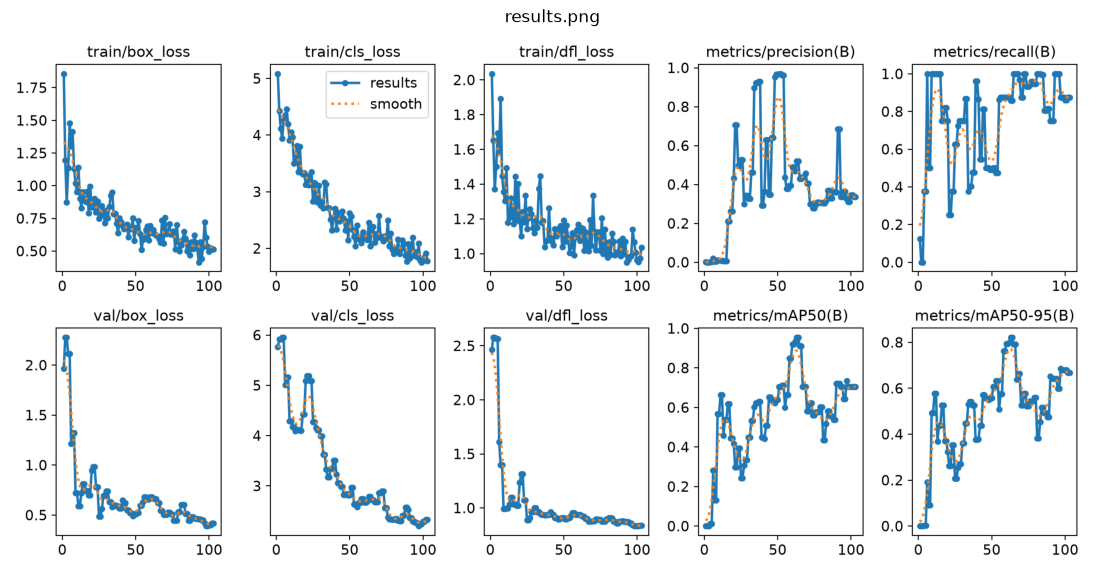

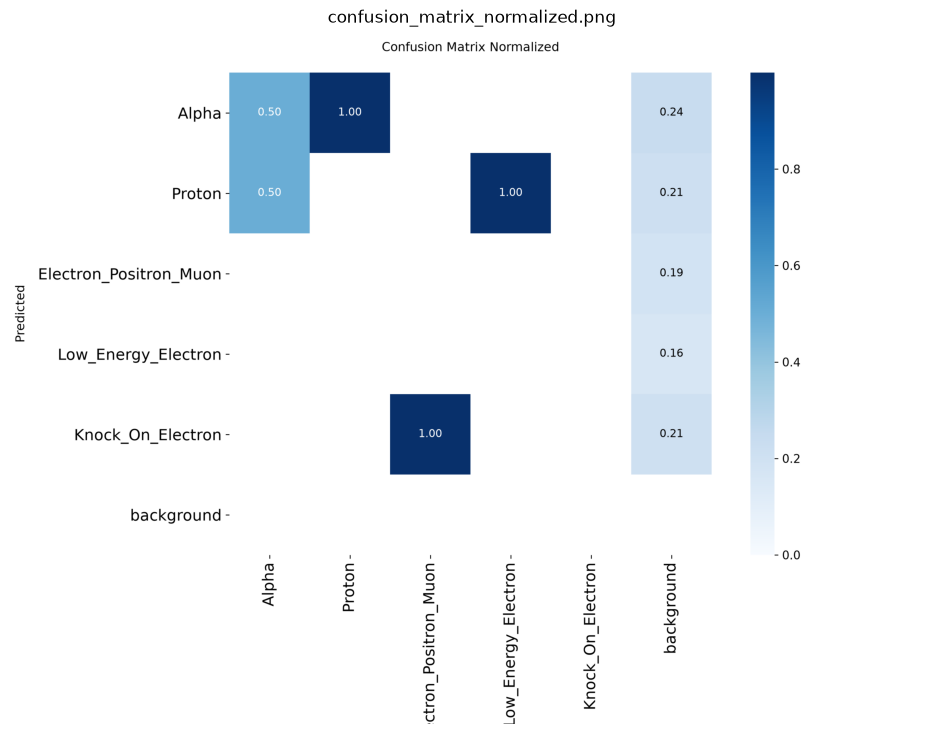

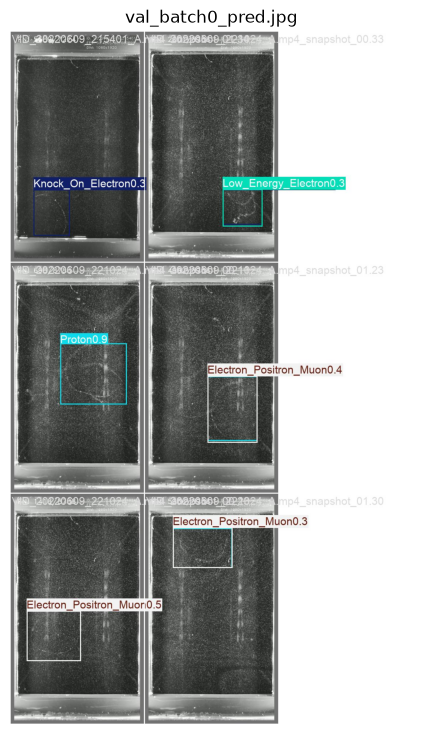

In [ ]:
run_dir = os.path.join(config.RUNS_DIR, config.PROJECT_NAME, config.RUN_NAME)

for plot_name in ["results.png", "confusion_matrix_normalized.png", "val_batch0_pred.jpg"]:
    p = os.path.join(run_dir, plot_name)
    if os.path.isfile(p):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(14, 9))
        plt.imshow(img)
        plt.title(plot_name)
        plt.axis("off")
        plt.show()
    else:
        print(f"(not found yet: {plot_name} — run training first)")


## 6. Inference on a single image

Load the trained weights (falls back to the base model if training hasn't produced
`best.pt` yet) and run detection on one image.


Image: VID_20220609_215401_A.mp4_snapshot_01.34_[2022.06.10_12.58.26].jpg
Detections: 2
  Low_Energy_Electron      conf=0.98  bbox=(173, 1330, 465, 1723)
  Knock_On_Electron        conf=0.57  bbox=(173, 1330, 462, 1717)


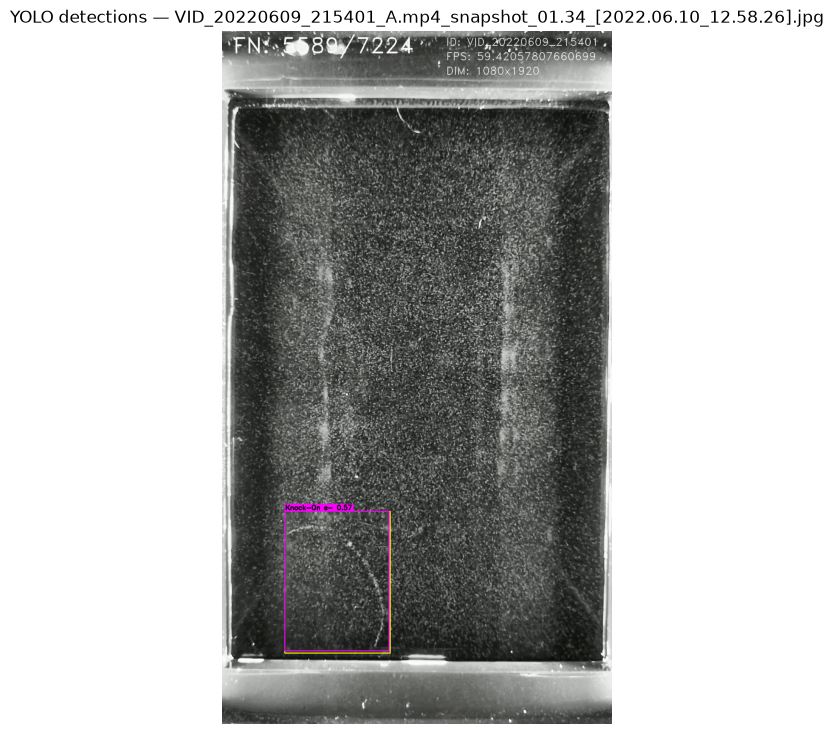

In [2]:
model = inference.load_model()  # uses config.BEST_WEIGHTS, or base model if missing

# Pick a validation image to test on.
val_img_dir = os.path.join(config.DATASET_DIR, "images", "val")
val_images = sorted(os.listdir(val_img_dir))
test_img_path = os.path.join(val_img_dir, val_images[0])

annotated, detections = inference.detect_image(model, test_img_path)

print(f"Image: {val_images[0]}")
print(f"Detections: {len(detections)}")
for d in detections:
    print(f"  {d['class_name']:24s} conf={d['confidence']:.2f}  bbox={d['bbox']}")

plt.figure(figsize=(14, 9))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"YOLO detections — {val_images[0]}")
plt.axis("off")
plt.show()


## 7. Inference on video

Run the detector frame-by-frame over a cloud-chamber video and write an annotated MP4 to
`config.VIDEO_OUTPUT`.

> On CPU this is slow for a full clip. Use `max_frames` to preview a short segment first.
> Set `VIDEO_INPUT` in `config.py` (or pass `input_path=...`) to point at your clip.


In [ ]:
# Preview the first 30 frames (set max_frames=None for the whole video).
video_stats = inference.process_video(
    model,
    input_path=config.VIDEO_INPUT,
    output_path=config.VIDEO_OUTPUT,
    max_frames=30,
)
video_stats


Video: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\Videos\test_vid_cropped.mp4
  Resolution: 1080x1722  FPS: 29.7  Frames: 4299
  Frame 100/4299 (2.3%) — 10 detections so far
  Frame 200/4299 (4.7%) — 19 detections so far
  Frame 300/4299 (7.0%) — 25 detections so far
  Frame 400/4299 (9.3%) — 36 detections so far
  Frame 500/4299 (11.6%) — 51 detections so far
  Frame 600/4299 (14.0%) — 57 detections so far
  Frame 700/4299 (16.3%) — 75 detections so far
  Frame 800/4299 (18.6%) — 82 detections so far
  Frame 900/4299 (20.9%) — 88 detections so far
  Frame 1000/4299 (23.3%) — 96 detections so far

PROCESSING COMPLETE
Output saved to: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\YOLO\output_yolo.mp4
Frames processed: 1000
Total detections: 96

Detections per class:
  Alpha: 15
  Proton: 1
  Electron_Positron_Muon: 2
  Low_Energy_Electron: 2
  Knock_On_Electron: 76


{'frames': 1000,
 'total_detections': 96,
 'class_counts': {0: 15, 1: 1, 2: 2, 3: 2, 4: 76},
 'output_path': 'c:\\Users\\PC\\Desktop\\RSW Coursework\\Y3S1\\Image Processing\\Jun\\YOLO\\output_yolo.mp4'}

## 8. Improving recall (catching more tracks)

Whole-frame, high-confidence inference misses most of the faint tracks in the video.
The pipeline now includes several recall-oriented improvements (all toggled in `config.py`):

- **CLAHE enhancement** (`preprocessing.py`) — applied identically to training images and
  inference frames so faint, low-contrast tracks stand out and the domains match.
- **Low confidence threshold** (`CONF_THRESHOLD = 0.10`) — favours recall.
- **Test-time augmentation** (`USE_TTA`) — multi-scale + flipped inference.
- **Tiled / SAHI-style inference** (`USE_TILING`) — slices each high-res frame into
  overlapping tiles, detects per tile, and merges with class-wise NMS. This is the biggest
  win for small tracks.

> **Root cause, though, is the data.** Only ~32 images with ~7 boxes/class are labelled,
> and most visible tracks in each frame are left unlabelled — so the model is actively
> taught to treat faint tracks as background. Use `extract_frames.py` to sample more frames
> and label **every** visible track, then rebuild and retrain. The tricks above help, but
> denser labels are what will actually fix detection.

The cell below compares whole-frame vs enhanced+tiled detection on one image.


Whole-frame @0.25   : 2 detections
Enhanced+tiled+TTA  : 1 detections


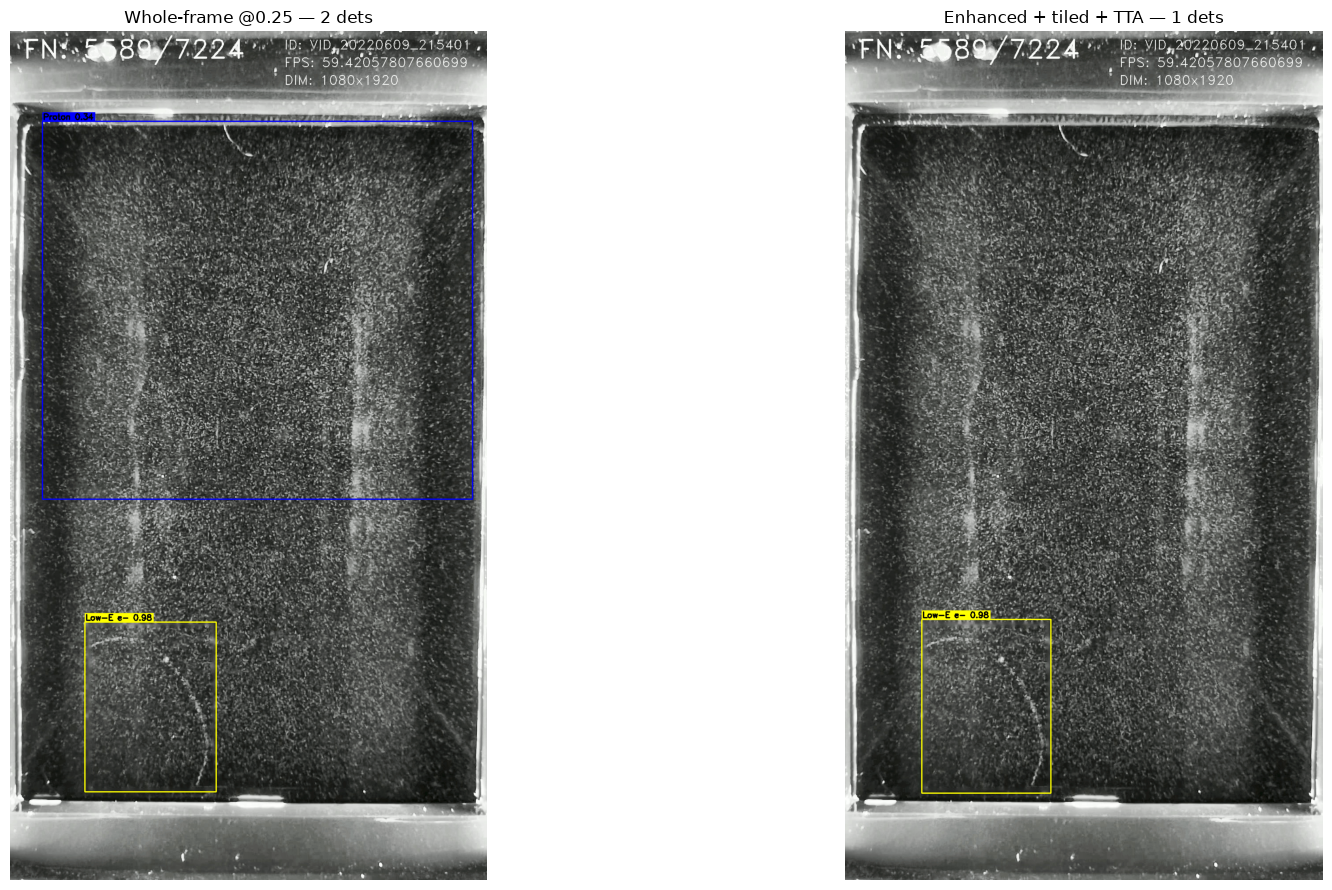

In [3]:
import importlib
import preprocessing
importlib.reload(config)          # pick up new preprocessing/inference settings
importlib.reload(preprocessing)
importlib.reload(inference)

# Compare plain whole-frame detection vs enhanced + tiled + TTA on one val image.
plain_annot, plain_dets = inference.detect_image(
    model, test_img_path, conf=0.25, use_tiling=False, use_tta=False,
)
boosted_annot, boosted_dets = inference.detect_image(
    model, test_img_path, use_tiling=True, use_tta=True,
)

print(f"Whole-frame @0.25   : {len(plain_dets)} detections")
print(f"Enhanced+tiled+TTA  : {len(boosted_dets)} detections")

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
axes[0].imshow(cv2.cvtColor(plain_annot, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Whole-frame @0.25 — {len(plain_dets)} dets")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(boosted_annot, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Enhanced + tiled + TTA — {len(boosted_dets)} dets")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 9. Expand the dataset (the real fix)

Sample more frames from the source videos so you can label them densely. Annotate
**every** visible track in each extracted frame (LabelImg / Roboflow / CVAT → YOLO txt),
then rebuild the dataset and retrain. Frames are CLAHE-enhanced to match the pipeline.


In [ ]:
import extract_frames

# Sample one frame every 30 frames from every video in ../Videos.
# Tune `every` lower for more frames. Output goes to YOLO/extracted_frames/.
n_saved = extract_frames.extract_all(every=30)
print(f"\nExtracted {n_saved} frames for annotation -> {extract_frames.FRAMES_OUT_DIR}")
